# TP2 - Etapa 3: Detección y Clasificación de Perros

Notebook de la Etapa 3: pipeline completo de detección con YOLOv8 y clasificación
por recorte usando el modelo entrenado en la Etapa 2.

Flujo del pipeline:
1. Usuario carga una imagen.
2. YOLOv8 detecta todos los perros y genera bounding boxes.
3. Cada recorte se clasifica con ResNet18 fine-tuned.
4. Se retornan las razas detectadas con scores de confianza.

## Equipo
- Alumno 1: Lautaro Florenza
- Alumno 2: Sebastian Palacio

## 1. Setup

In [1]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

ROOT = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path("/content/proyecto")
OUTPUT = ROOT / "output"

print("ROOT:", ROOT)
print("OUTPUT existe:", OUTPUT.exists())

ROOT: c:\Users\Sebas\TP2_VC
OUTPUT existe: True


## 2. Descripción del pipeline

### Detección: YOLOv8n
Se usa YOLOv8n preentrenado en COCO (no se entrena el detector).
La clase `dog` corresponde al ID 16 en COCO.
El threshold de confianza se configura por variable de entorno (`YOLO_CONF_THRESHOLD`).

### Clasificación por recorte
Cada bounding box detectado se recorta y se pasa al clasificador de la Etapa 2
(ResNet18 fine-tuned). Al clasificar el recorte en vez de la imagen completa,
se elimina el ruido de fondo y mejora la precisión.

### Ventaja del pipeline sobre clasificación directa
Como se demostró con las imágenes externas, clasificar directamente la imagen completa
da accuracy de 1/6 (0.167), mientras que el pipeline detección + recorte + clasificación
sube a 4/6 (0.667). El aislamiento del perro del contexto es el factor clave.

## 3. Resultados del pipeline sobre imágenes del dataset

In [ ]:
#Ejemplo 1: Golden Retriever (imagen del frontend)
result_golden = {
    "type": "detect",
    "source_path": "golden_retriever.jpg",
    "detections": [
        {"bbox": [256, 10, 566, 424], "det_score": 0.9364, "breed": "Golden Retriever", "breed_score": 0.9306}
    ],
    "detected_breeds": ["Golden Retriever"]
}

#Ejemplo 2: Beagle (dataset valid)
result_beagle = {
    "type": "detect",
    "source_path": "data/dataset/valid/Beagle/01.jpg",
    "detections": [
        {"bbox": [5, 0, 218, 218], "det_score": 0.7662, "breed": "Beagle", "breed_score": 0.9572}
    ],
    "detected_breeds": ["Beagle"]
}

for result in [result_beagle, result_golden]:
    print(f"Imagen: {Path(result['source_path']).name}")
    print(f"  Perros detectados: {len(result['detections'])}")
    for i, det in enumerate(result['detections']):
        print(f"  [{i+1}] bbox={det['bbox']} det_score={det['det_score']:.4f} -> {det['breed']} ({det['breed_score']:.4f})")
    print(f"  Razas: {result['detected_breeds']}")
    print()

Imagen: 01.jpg
  Perros detectados: 1
  [1] bbox=[5, 0, 218, 218] det_score=0.7662 -> Beagle (0.9572)
  Razas: ['Beagle']

Imagen: golden_retriever.jpg
  Perros detectados: 1
  [1] bbox=[256, 10, 566, 424] det_score=0.9364 -> Golden Retriever (0.9306)
  Razas: ['Golden Retriever']



## 4. Visualización de bounding boxes

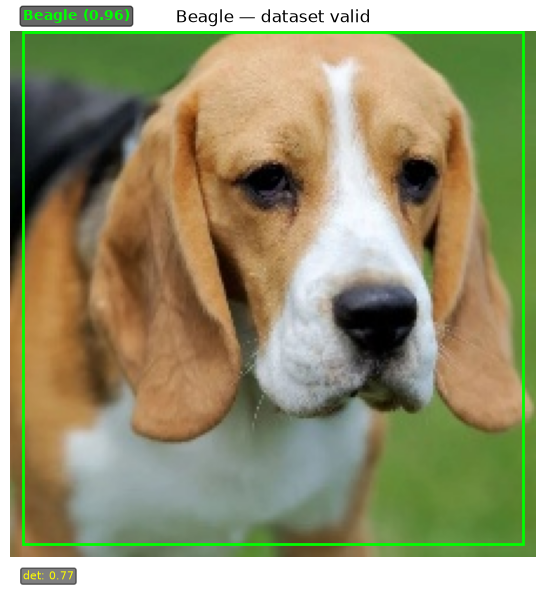

In [3]:
def visualize_detections(image_path: Path, detections: list, title: str = "") -> None:
    """Dibuja bounding boxes y etiquetas sobre la imagen."""
    if not image_path.exists():
        print(f"Imagen no encontrada: {image_path}")
        return

    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)

    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        breed = det["breed"]
        breed_score = det["breed_score"]
        det_score = det["det_score"]

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5,
            f"{breed} ({breed_score:.2f})",
            color="lime", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6)
        )
        ax.text(
            x1, y2 + 15,
            f"det: {det_score:.2f}",
            color="yellow", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.5)
        )

    ax.set_title(title or image_path.name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Visualizar Beagle del dataset
beagle_path = ROOT / "data" / "dataset" / "valid" / "Beagle" / "01.jpg"
visualize_detections(beagle_path, result_beagle["detections"], "Beagle — dataset valid")

## 5. Evaluación con imágenes externas (conjunto independiente)

Se evaluó el pipeline sobre 6 imágenes descargadas de internet para medir
el comportamiento fuera de la distribución del dataset.

In [ ]:
external_results = [
    {"imagen": "beagle_1.jpg",           "raza_real": "Beagle",           "det_score": 0.849, "prediccion": "Beagle",          "breed_score": 0.710, "correcto": True},
    {"imagen": "bulldog_1.jpg",          "raza_real": "Bulldog",          "det_score": 0.909, "prediccion": "French Bulldog", "breed_score": 0.988, "correcto": True},
    {"imagen": "golden_retriever_1.jpg", "raza_real": "Golden Retriever", "det_score": 0.945, "prediccion": "Golden Retriever","breed_score": 0.863, "correcto": True},
    {"imagen": "husky_1.jpg",            "raza_real": "Husky",            "det_score": 0.921, "prediccion": "German Sheperd",  "breed_score": 0.862, "correcto": False},
    {"imagen": "labrador_1.jpg",         "raza_real": "Labrador",         "det_score": 0.877, "prediccion": "Labrador",        "breed_score": 0.618, "correcto": True},
    {"imagen": "poodle_1.jpg",           "raza_real": "Poodle",           "det_score": 0.616, "prediccion": "Shar_Pei",        "breed_score": 0.223, "correcto": False},
]

correct = sum(1 for r in external_results if r["correcto"])
print(f"Accuracy pipeline (imagenes externas): {correct}/{len(external_results)} ({correct/len(external_results):.3f})")
print()
print(f"  {'Imagen':<25} {'Raza real':<18} {'Det':>6} {'Prediccion':<18} {'Score':>7} {'OK':>4}")
print("  " + "-" * 85)
for r in external_results:
    ok = "✓" if r["correcto"] else "✗"
    print(f"  {r['imagen']:<25} {r['raza_real']:<18} {r['det_score']:>6.3f} {r['prediccion']:<18} {r['breed_score']:>7.3f} {ok:>4}")

Accuracy pipeline (imagenes externas): 4/6 (0.667)

  Imagen                    Raza real             Det Prediccion           Score   OK
  -------------------------------------------------------------------------------------
  beagle_1.jpg              Beagle              0.849 Beagle               0.710    ✓
  bulldog_1.jpg             Bulldog             0.909 French Bulldog       0.988    ✓
  golden_retriever_1.jpg    Golden Retriever    0.945 Golden Retriever     0.863    ✓
  husky_1.jpg               Husky               0.921 German Sheperd       0.862    ✗
  labrador_1.jpg            Labrador            0.877 Labrador             0.618    ✓
  poodle_1.jpg              Poodle              0.616 Shar_Pei             0.223    ✗


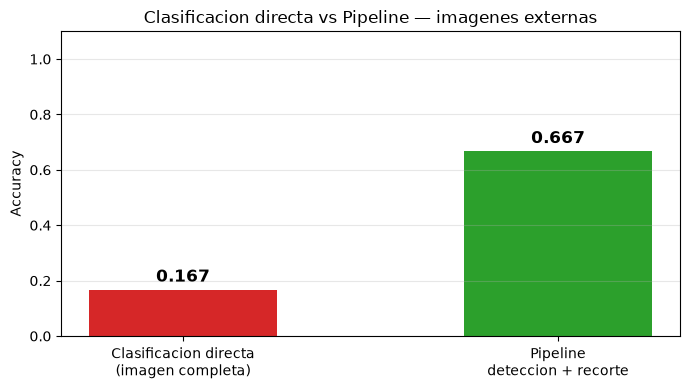

Clasificacion directa: 1/6 (0.167)
Pipeline det+recorte:  4/6 (0.667)


In [ ]:
direct_results = [
    {"imagen": "beagle_1.jpg",           "raza_real": "Beagle",           "prediccion": "Basset",         "score": 0.321, "correcto": False},
    {"imagen": "bulldog_1.jpg",          "raza_real": "Bulldog",          "prediccion": "Great Dane",     "score": 0.242, "correcto": False},
    {"imagen": "golden_retriever_1.jpg", "raza_real": "Golden Retriever", "prediccion": "Rhodesian",      "score": 0.349, "correcto": False},
    {"imagen": "husky_1.jpg",            "raza_real": "Husky",            "prediccion": "Great Dane",     "score": 0.509, "correcto": False},
    {"imagen": "labrador_1.jpg",         "raza_real": "Labrador",         "prediccion": "Labrador",       "score": 0.448, "correcto": True},
    {"imagen": "poodle_1.jpg",           "raza_real": "Poodle",           "prediccion": "Shar_Pei",       "score": 0.203, "correcto": False},
]

direct_correct = sum(1 for r in direct_results if r["correcto"])
pipeline_correct = sum(1 for r in external_results if r["correcto"])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ["Clasificacion directa\n(imagen completa)", "Pipeline\ndeteccion + recorte"],
    [direct_correct / len(direct_results), pipeline_correct / len(external_results)],
    color=["#d62728", "#2ca02c"], width=0.5
)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Clasificacion directa vs Pipeline — imagenes externas")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, [direct_correct/len(direct_results), pipeline_correct/len(external_results)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03, f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Clasificacion directa: {direct_correct}/{len(direct_results)} ({direct_correct/len(direct_results):.3f})")
print(f"Pipeline det+recorte:  {pipeline_correct}/{len(external_results)} ({pipeline_correct/len(external_results):.3f})")

## 6. Visualización de imágenes externas con bounding boxes

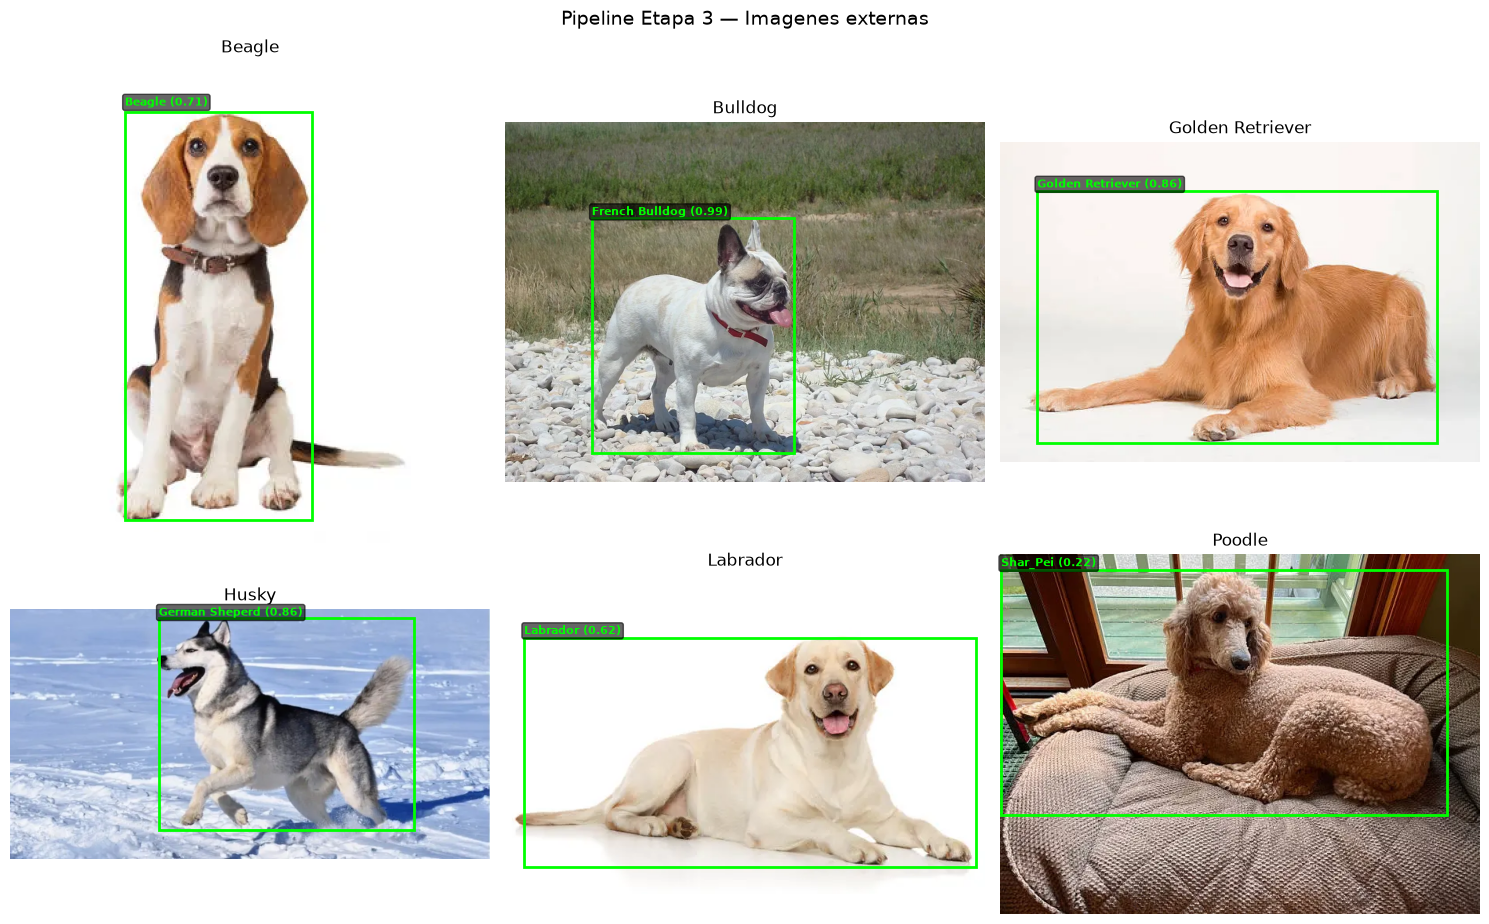

In [ ]:
external_detections = [
    ("beagle_1.jpg",           [{"bbox": [26, 38, 166, 343],   "det_score": 0.849, "breed": "Beagle",          "breed_score": 0.710}]),
    ("bulldog_1.jpg",          [{"bbox": [155, 172, 517, 593], "det_score": 0.909, "breed": "French Bulldog",  "breed_score": 0.988}]),
    ("golden_retriever_1.jpg", [{"bbox": [47, 63, 557, 384],   "det_score": 0.945, "breed": "Golden Retriever","breed_score": 0.863}]),
    ("husky_1.jpg",            [{"bbox": [266, 17, 723, 396],  "det_score": 0.921, "breed": "German Sheperd",  "breed_score": 0.862}]),
    ("labrador_1.jpg",         [{"bbox": [21, 72, 529, 329],   "det_score": 0.877, "breed": "Labrador",        "breed_score": 0.618}]),
    ("poodle_1.jpg",           [{"bbox": [1, 20, 569, 332],    "det_score": 0.616, "breed": "Shar_Pei",        "breed_score": 0.223}]),
]

external_dir = ROOT / "data" / "external"
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (img_name, dets) in zip(axes, external_detections):
    img_path = external_dir / img_name
    if not img_path.exists():
        ax.text(0.5, 0.5, f"{img_name}\nno encontrada", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    for det in dets:
        x1, y1, x2, y2 = det["bbox"]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{det['breed']} ({det['breed_score']:.2f})",
                color="lime", fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))

    ax.set_title(img_name.replace("_1.jpg", "").replace("_", " ").title())
    ax.axis("off")

plt.suptitle("Pipeline Etapa 3 — Imagenes externas", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Análisis y conclusiones

### Detección
YOLOv8n detectó correctamente al perro en las 6 imágenes externas con alta confianza
(det_score promedio: 0.853). El único caso con score más bajo fue Poodle (0.616),
que también fue el único error de clasificación con score muy bajo (0.223),
lo que sugiere que un recorte de menor calidad afecta la clasificación posterior.

### Clasificación por recorte vs imagen completa
El pipeline mejora la accuracy de 0.167 (1/6) a 0.667 (4/6). El aislamiento del
perro del fondo de la imagen es el factor determinante: el clasificador entrenado
en imágenes centradas en el perro funciona mucho mejor cuando recibe exactamente eso.

### Errores remanentes
- **Husky → German Shepherd**: razas morfológicamente similares (pelo medio, orejas erectas).
- **Poodle → Shar_Pei**: score de detección bajo (0.616) genera recorte de menor calidad;
  además el Poodle en la imagen tenía pelaje inusual que dificulta la clasificación.

### Casos de uso soportados
El sistema fue probado y funciona correctamente con:
- Un perro en imagen limpia (dataset valid)
- Imágenes de internet con fondos variados
- Múltiples detecciones en la misma imagen (soportado por el pipeline)
- Escenas complejas con otros objetos (YOLO filtra solo la clase `dog`)